In [22]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')


In [23]:
# Data Download
df = yf.download('SPY', start='2016-01-01', end='2026-12-31',auto_adjust=False, interval='1d',multi_level_index=False)

# Cleaning Data
df.drop(columns=['Close','High','Low','Open','Volume'], inplace=True)
df.dropna(inplace=True)

# Model Training
window = 200
pred = []
dates = []
for i in range(window,len(df)):

    train = df['Adj Close'].iloc[i-window:i]

    model = ARIMA(train,order=(1,0,0)).fit()
    forecast = model.forecast(steps=1)

    pred.append(forecast.iloc[0])
    dates.append(df.index[i])


pred_series = pd.Series(pred,index = dates)
df['prediction'] = pred_series
df.dropna(inplace=True)


[*********************100%***********************]  1 of 1 completed


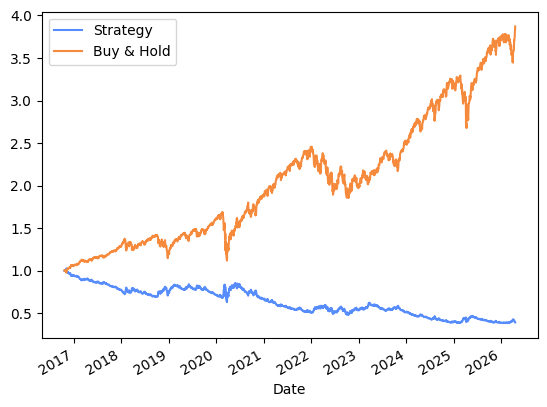

In [24]:
df['prev_close'] = df['Adj Close'].shift(1)

df['signal'] = 0

df.loc[df['prediction'] > df['prev_close'], 'signal'] = 1
df.loc[df['prediction'] < df['prev_close'], 'signal'] = -1

df['position'] = df['signal']

returns = df['Adj Close'].pct_change()
df['strategy_return'] = df['position'] * returns
strategy_cum = (1 + df['strategy_return']).cumprod()
buy_hold = (1 + returns).cumprod()

strategy_cum.plot(label='Strategy')
buy_hold.plot(label='Buy & Hold')
plt.legend()
plt.show()

print("Buy and Hold Returns",strategy_cum)
